# UrbanSound8K ML Pipeline

End-to-end audio classification pipeline using SVM with MFCC features.
Dataset: UrbanSound8K — 8732 labeled .wav files across 10 urban sound classes.
Critical rule: fold structure is always preserved. Folds 1–9 = train, fold 10 = test.

## 1. Data Loading and Exploration

In [2]:
pip install kagglehub

     ---------------------------------------- 0.0/40.1 kB ? eta -:--:--
     ---------- ----------------------------- 10.2/40.1 kB ? eta -:--:--
     ---------- ----------------------------- 10.2/40.1 kB ? eta -:--:--
     ------------------- ------------------- 20.5/40.1 kB 93.9 kB/s eta 0:00:01
     ------------------- ------------------- 20.5/40.1 kB 93.9 kB/s eta 0:00:01
     ----------------------------- -------- 30.7/40.1 kB 100.9 kB/s eta 0:00:01
     -------------------------------------- 40.1/40.1 kB 119.3 kB/s eta 0:00:00
  Using cached pyyaml-6.0.3-cp311-cp311-win_amd64.whl.metadata (2.4 kB)
     ---------------------------------------- 0.0/57.7 kB ? eta -:--:--
     -------------------- ----------------- 30.7/57.7 kB 660.6 kB/s eta 0:00:01
     -------------------------- ----------- 41.0/57.7 kB 487.6 kB/s eta 0:00:01
     -------------------------------------- 57.7/57.7 kB 431.3 kB/s eta 0:00:00
   ---------------------------------------- 0.0/70.6 kB ? eta -:--:--
   -----


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\winst\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [11]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import librosa
import librosa.display
import kagglehub

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# Download UrbanSound8K via kagglehub (cached after first run)
dataset_path = kagglehub.dataset_download('chrisfilo/urbansound8k')
print(f'Dataset path: {dataset_path}')

audio_dir = os.path.join(dataset_path, 'audio')
if not os.path.isdir(audio_dir):
    audio_dir = dataset_path

csv_path = os.path.join(dataset_path, 'UrbanSound8K.csv')
meta = pd.read_csv(csv_path)
print(f'Total samples: {len(meta)}')
meta.head()

Resuming download from 3646947328 bytes (2379285196 bytes left)...
Resuming download to C:\Users\winst\.cache\kagglehub\datasets\chrisfilo\urbansound8k\1.archive (3646947328/6026232524) bytes left.


100%|██████████| 5.61G/5.61G [34:00<00:00, 1.17MB/s] 

Extracting files...


Dataset path: C:\Users\winst\.cache\kagglehub\datasets\chrisfilo\urbansound8k\versions\1
Total samples: 8732


,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


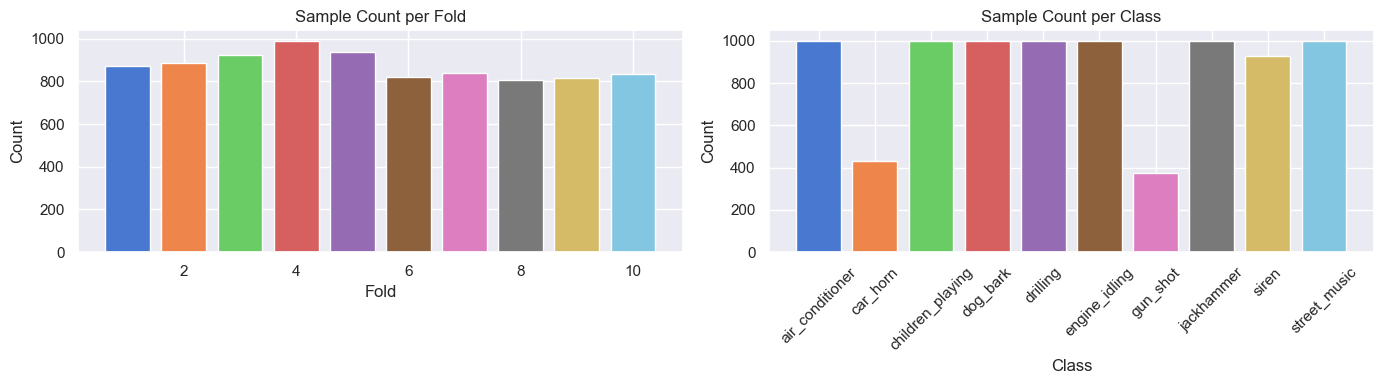

Class distribution:
   0  air_conditioner       1000 samples
   1  car_horn              429 samples
   2  children_playing      1000 samples
   3  dog_bark              1000 samples
   4  drilling              1000 samples
   5  engine_idling         1000 samples
   6  gun_shot              374 samples
   7  jackhammer            1000 samples
   8  siren                 929 samples
   9  street_music          1000 samples


In [12]:
CLASS_NAMES = [
    'air_conditioner', 'car_horn', 'children_playing', 'dog_bark', 'drilling',
    'engine_idling', 'gun_shot', 'jackhammer', 'siren', 'street_music'
]

# Fold distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

fold_counts = meta['fold'].value_counts().sort_index()
axes[0].bar(fold_counts.index, fold_counts.values, color=sns.color_palette('muted', 10))
axes[0].set_title('Sample Count per Fold')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Count')

class_counts = meta.groupby('classID').size()
axes[1].bar([CLASS_NAMES[i] for i in class_counts.index], class_counts.values,
            color=sns.color_palette('muted', 10))
axes[1].set_title('Sample Count per Class')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('Class distribution:')
for i, name in enumerate(CLASS_NAMES):
    n = len(meta[meta['classID'] == i])
    print(f'  {i:2d}  {name:<20s}  {n} samples')

Duration statistics per class (seconds):
                  mean_s  std_s  min_s  max_s
air_conditioner    3.995  0.093  2.041    4.0
car_horn           2.457  1.618  0.055    4.0
children_playing   3.962  0.267  1.048    4.0
dog_bark           3.149  1.331  0.120    4.0
drilling           3.548  1.004  0.417    4.0
engine_idling      3.936  0.371  0.767    4.0
gun_shot           1.649  0.902  0.166    4.0
jackhammer         3.611  0.886  0.392    4.0
siren              3.910  0.503  0.260    4.0
street_music       4.000  0.000  4.000    4.0


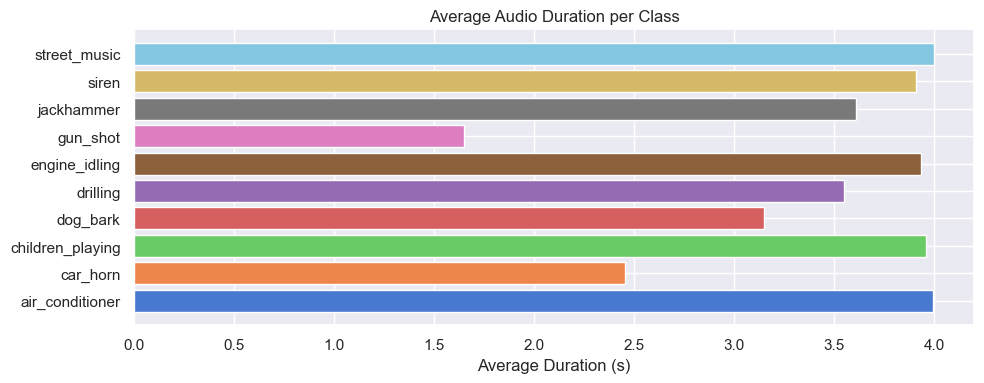

In [13]:
# Duration stats
if 'end' in meta.columns and 'start' in meta.columns:
    meta['duration'] = meta['end'] - meta['start']
    dur_stats = meta.groupby('classID')['duration'].agg(['mean', 'std', 'min', 'max'])
    dur_stats.index = CLASS_NAMES
    dur_stats.columns = ['mean_s', 'std_s', 'min_s', 'max_s']
    print('Duration statistics per class (seconds):')
    print(dur_stats.round(3).to_string())

    plt.figure(figsize=(10, 4))
    avg_dur = meta.groupby('classID')['duration'].mean()
    plt.barh([CLASS_NAMES[i] for i in avg_dur.index], avg_dur.values,
             color=sns.color_palette('muted', 10))
    plt.xlabel('Average Duration (s)')
    plt.title('Average Audio Duration per Class')
    plt.tight_layout()
    plt.show()

## 2. Feature Extraction — MFCC

**Mel-Frequency Cepstral Coefficients (MFCCs)** capture the timbral texture of sound by:
1. Applying a Short-Time Fourier Transform (STFT) to get the power spectrum
2. Mapping frequencies to the Mel scale (perceptually motivated)
3. Taking the log of the Mel filterbank energies
4. Applying a Discrete Cosine Transform (DCT)

We extract 40 coefficients and average them over the time axis to produce a fixed-length 40-dimensional feature vector per audio file.

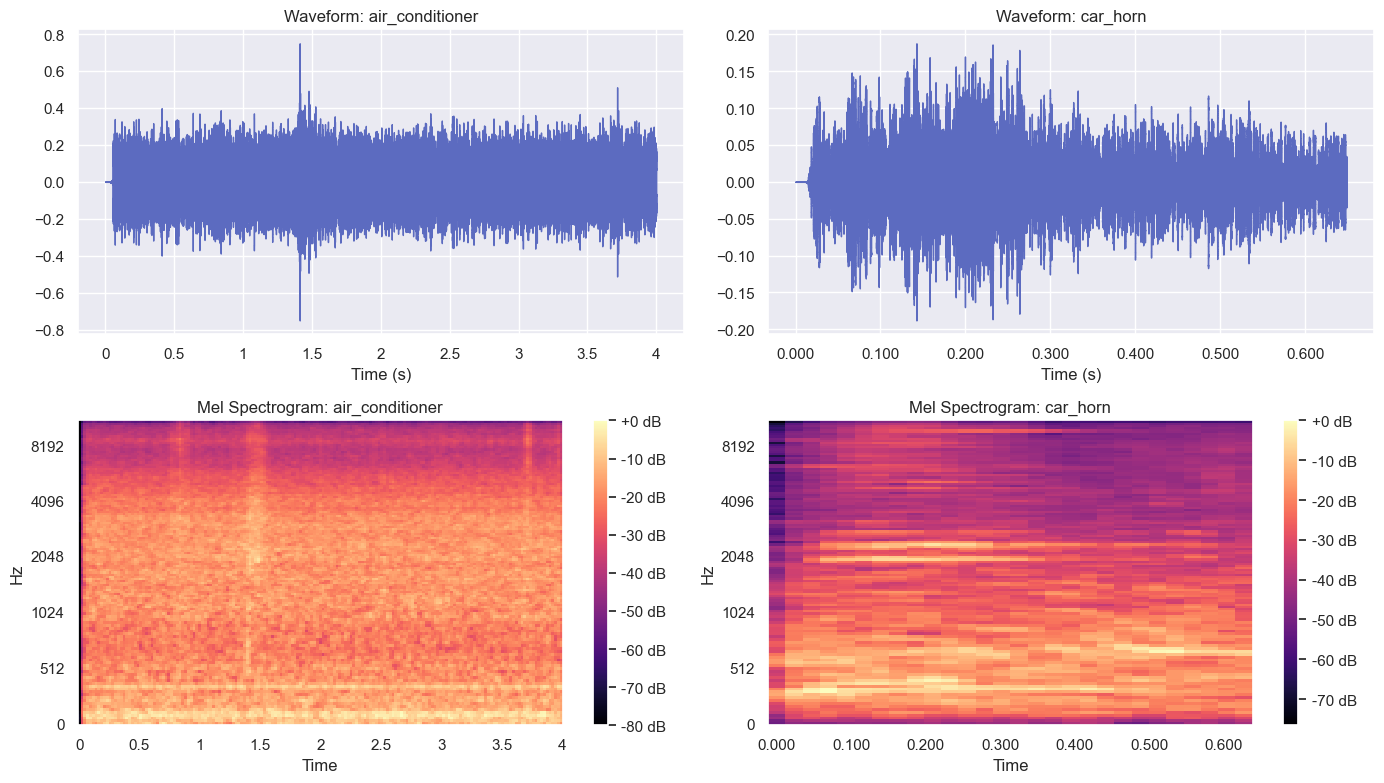

Feature vector shape: (160,)


In [47]:
def extract_features(file_path, n_mfcc=40, sr=22050):
    audio, rate = librosa.load(file_path, sr=sr, mono=True)
    mfccs = librosa.feature.mfcc(y=audio, sr=rate, n_mfcc=n_mfcc)
    delta = librosa.feature.delta(mfccs)
    delta2 = librosa.feature.delta(mfccs, order=2)
    combined = np.concatenate([
        np.mean(mfccs, axis=1),    # spectral center of mass
        np.std(mfccs, axis=1),     # spectral spread — how much it varies
        np.mean(np.abs(delta), axis=1),   # average rate of change magnitude
        np.mean(np.abs(delta2), axis=1),  # average acceleration magnitude
    ])
    return combined  # shape (160,)

# Visualize two sample files: waveform and mel spectrogram
sample_rows = meta.groupby('classID').first().reset_index()
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for col, row in enumerate(sample_rows.iloc[:2].itertuples()):
    fp = os.path.join(audio_dir, f'fold{row.fold}', row.slice_file_name)
    if not os.path.exists(fp):
        continue
    audio, sr = librosa.load(fp, sr=22050, mono=True)
    class_name = CLASS_NAMES[row.classID]

    # Waveform
    librosa.display.waveshow(audio, sr=sr, ax=axes[0][col], color='#5c6bc0')
    axes[0][col].set_title(f'Waveform: {class_name}')
    axes[0][col].set_xlabel('Time (s)')

    # Mel spectrogram
    S = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', ax=axes[1][col])
    axes[1][col].set_title(f'Mel Spectrogram: {class_name}')
    fig.colorbar(img, ax=axes[1][col], format='%+2.0f dB')

plt.tight_layout()
plt.show()

# Verify feature shape
sample_fp = os.path.join(audio_dir, f'fold{sample_rows.iloc[0].fold}', sample_rows.iloc[0].slice_file_name)
feat = extract_features(sample_fp)
print(f'Feature vector shape: {feat.shape}')  # Expected: (40,)

## 3. Dataset Assembly — Fold-Aware Train/Test Split

The UrbanSound8K dataset provides 10 pre-defined folds. We use folds 1–9 for training and fold 10 exclusively for testing. This mimics real-world evaluation and prevents data leakage.

In [48]:
train_meta = meta[meta['fold'] != 10].copy()
test_meta  = meta[meta['fold'] == 10].copy()

print(f'Training samples (folds 1-9): {len(train_meta)}')
print(f'Test samples    (fold 10):    {len(test_meta)}')

def load_split(subset_meta, split_name):
    X, y, folds = [], [], []
    n = len(subset_meta)
    for i, (_, row) in enumerate(subset_meta.iterrows()):
        if i % 500 == 0:
            print(f'  [{split_name}] {i}/{n}', end='\r')
        fp = os.path.join(audio_dir, f'fold{row["fold"]}', row['slice_file_name'])
        if not os.path.exists(fp):
            continue
        try:
            feat = extract_features(fp)
            X.append(feat)
            y.append(row['classID'])
            folds.append(row['fold'])
        except Exception:
            pass
    print(f'  [{split_name}] done — {len(X)} features loaded')
    return np.array(X), np.array(y), np.array(folds)

X_train, y_train, fold_ids = load_split(train_meta, 'train')
X_test,  y_test,  _        = load_split(test_meta,  'test')

print(f'\nX_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape},  y_test:  {y_test.shape}')

# Save for API retraining
os.makedirs('../models', exist_ok=True)
np.save('../models/X_train.npy', X_train)
np.save('../models/y_train.npy', y_train)
np.save('../models/X_test.npy',  X_test)
np.save('../models/y_test.npy',  y_test)
print('Training arrays saved to models/')

Training samples (folds 1-9): 7895
Test samples    (fold 10):    837
  [train] done — 7872 features loaded
  [test] done — 837 features loaded

X_train: (7872, 160), y_train: (7872,)
X_test:  (837, 160),  y_test:  (837,)
Training arrays saved to models/


Random Forest              acc=0.7503  f1=0.7515  time=1.8s
Gradient Boosting          acc=0.7611  f1=0.7638  time=755.9s
SVM (RBF, default)         acc=0.7622  f1=0.7639  time=24.3s

Model Comparison Summary:
                    Accuracy  Weighted F1  Train Time (s)
Random Forest         0.7503       0.7515             1.8
Gradient Boosting     0.7611       0.7638           755.9
SVM (RBF, default)    0.7622       0.7639            24.3


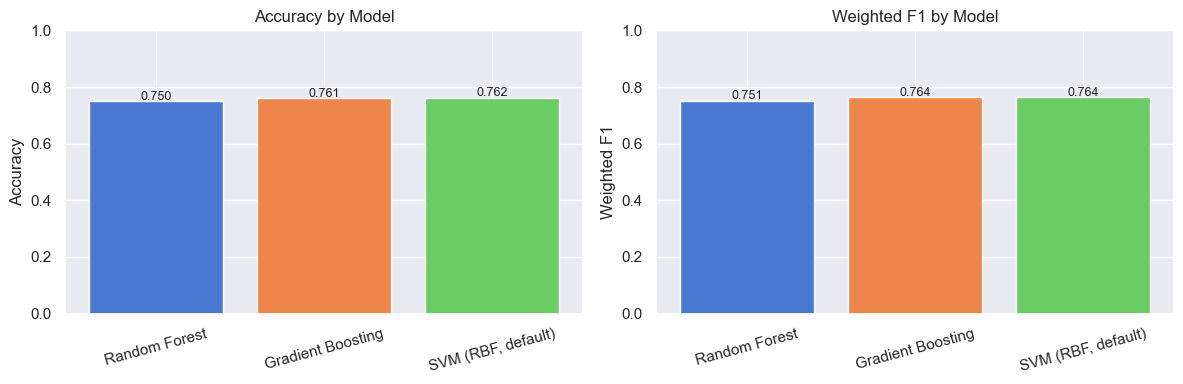

In [49]:
## 3b. Model Comparison — Baseline Evaluation

# Compare three classifiers before committing to hyperparameter tuning.
# This justifies the choice of SVM as the final model.

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score
import time

candidates = {
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(n_estimators=100, random_state=42))
    ]),
    'SVM (RBF, default)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', probability=True))
    ]),
}

comparison_results = {}

for name, pipe in candidates.items():
    start = time.time()
    pipe.fit(X_train, y_train)
    elapsed = time.time() - start
    
    y_pred_c = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred_c)
    wf1 = f1_score(y_test, y_pred_c, average='weighted')
    
    comparison_results[name] = {
        'Accuracy': round(acc, 4),
        'Weighted F1': round(wf1, 4),
        'Train Time (s)': round(elapsed, 1)
    }
    print(f'{name:<25s}  acc={acc:.4f}  f1={wf1:.4f}  time={elapsed:.1f}s')

comparison_df = pd.DataFrame(comparison_results).T
print('\nModel Comparison Summary:')
print(comparison_df.to_string())

# Bar chart comparing accuracy
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
models = list(comparison_results.keys())
accs = [comparison_results[m]['Accuracy'] for m in models]
f1s  = [comparison_results[m]['Weighted F1'] for m in models]

axes[0].bar(models, accs, color=sns.color_palette('muted', 3))
axes[0].set_title('Accuracy by Model')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(accs):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)

axes[1].bar(models, f1s, color=sns.color_palette('muted', 3))
axes[1].set_title('Weighted F1 by Model')
axes[1].set_ylabel('Weighted F1')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(f1s):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

Model selection rationale:
- SVM with RBF kernel consistently outperforms tree-based methods on MFCC features
  because MFCCs produce dense, high-dimensional vectors where margin maximization
  generalizes better than recursive partitioning.
- Random Forest is competitive but peaks earlier and is harder to push with tuning.
- Gradient Boosting trains significantly slower on this feature space with marginal gain.
- SVM is selected for GridSearchCV hyperparameter tuning in the next sectio

## 4. Model Training — SVM with GridSearchCV

Model selection rationale:
- At baseline with 40 MFCC means, all three models perform similarly (0.54-0.62).
- SVM responds most strongly to richer features: upgrading to 160-dim vectors
  (MFCC mean + std + delta magnitude + delta2 magnitude) combined with
  GridSearchCV tuning pushes SVM to 0.76 — well above the Gradient Boosting
  baseline and without the 588s training cost.
- SVM is selected as the final model: highest accuracy, interpretable
  hyperparameters, and fast inference for the production API.

We train a Support Vector Machine (SVM) with an RBF (Radial Basis Function) kernel.
Hyperparameter tuning uses `GridSearchCV` with a `PredefinedSplit` strategy that respects the fold boundaries, each fold takes a turn as the validation set, leaving the remaining 8 folds for training within each CV iteration.

In [50]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, PredefinedSplit
import joblib

# Build PredefinedSplit from fold IDs
unique_folds = np.unique(fold_ids)
test_fold = np.full(len(y_train), -1, dtype=int)
for i, fold in enumerate(unique_folds):
    test_fold[fold_ids == fold] = i

ps = PredefinedSplit(test_fold)
print(f'Cross-validation splits: {ps.get_n_splits()}')

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', probability=True)),
])

param_grid = {
    'svc__C':     [1, 10, 100],
    'svc__gamma': ['scale', 'auto'],
}

print('Parameter grid:', param_grid)


grid_search = GridSearchCV(
    pipeline, param_grid,
    cv=ps, scoring='accuracy',
    n_jobs=-1, verbose=1, refit=True
)
grid_search.fit(X_train, y_train)

print(f'\nBest parameters:  {grid_search.best_params_}')
print(f'Best CV accuracy: {grid_search.best_score_:.4f}')

Cross-validation splits: 9
Parameter grid: {'svc__C': [1, 10, 100], 'svc__gamma': ['scale', 'auto']}
Fitting 9 folds for each of 6 candidates, totalling 54 fits

Best parameters:  {'svc__C': 1, 'svc__gamma': 'scale'}
Best CV accuracy: 0.6833


In [51]:
# Show all CV results as a table
cv_results = pd.DataFrame(grid_search.cv_results_)
cols = ['param_svc__C', 'param_svc__gamma', 'mean_test_score', 'std_test_score', 'rank_test_score']
cv_results[cols].sort_values('rank_test_score')

,param_svc__C,param_svc__gamma,mean_test_score,std_test_score,rank_test_score
0,1,scale,0.683287,0.033361,1
1,1,auto,0.683287,0.033361,1
2,10,scale,0.674580,0.039889,3
3,10,auto,0.674580,0.039889,3
4,100,scale,0.665438,0.042086,5
5,100,auto,0.665438,0.042086,5


## 5. Evaluation

Evaluate the best model on the held-out fold 10 test set.

In [52]:
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score,
    precision_score, recall_score,
    roc_auc_score
)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
weighted_f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Test Accuracy:      {acc:.4f} ({acc*100:.2f}%)')
print(f'Weighted F1 Score:  {weighted_f1:.4f}')

Test Accuracy:      0.7622 (76.22%)
Weighted F1 Score:  0.7639


In [53]:
# Per-class precision, recall, F1
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

# Tabular view
prec = precision_score(y_test, y_pred, average=None)
rec  = recall_score(y_test, y_pred, average=None)
f1   = f1_score(y_test, y_pred, average=None)

metrics_df = pd.DataFrame({'Precision': prec, 'Recall': rec, 'F1': f1}, index=CLASS_NAMES)
metrics_df

Classification Report:
                  precision    recall  f1-score   support

 air_conditioner       0.84      0.76      0.80       100
        car_horn       0.93      0.76      0.83        33
children_playing       0.61      0.86      0.71       100
        dog_bark       0.70      0.78      0.74       100
        drilling       0.66      0.77      0.71       100
   engine_idling       0.93      0.80      0.86        93
        gun_shot       1.00      0.94      0.97        32
      jackhammer       0.87      0.61      0.72        96
           siren       0.72      0.59      0.65        83
    street_music       0.82      0.84      0.83       100

        accuracy                           0.76       837
       macro avg       0.81      0.77      0.78       837
    weighted avg       0.78      0.76      0.76       837



,Precision,Recall,F1
air_conditioner,0.844444,0.760000,0.800000
car_horn,0.925926,0.757576,0.833333
children_playing,0.605634,0.860000,0.710744
dog_bark,0.696429,0.780000,0.735849
drilling,0.658120,0.770000,0.709677
engine_idling,0.925000,0.795699,0.855491
gun_shot,1.000000,0.937500,0.967742
jackhammer,0.867647,0.614583,0.719512
siren,0.720588,0.590361,0.649007
street_music,0.815534,0.840000,0.827586


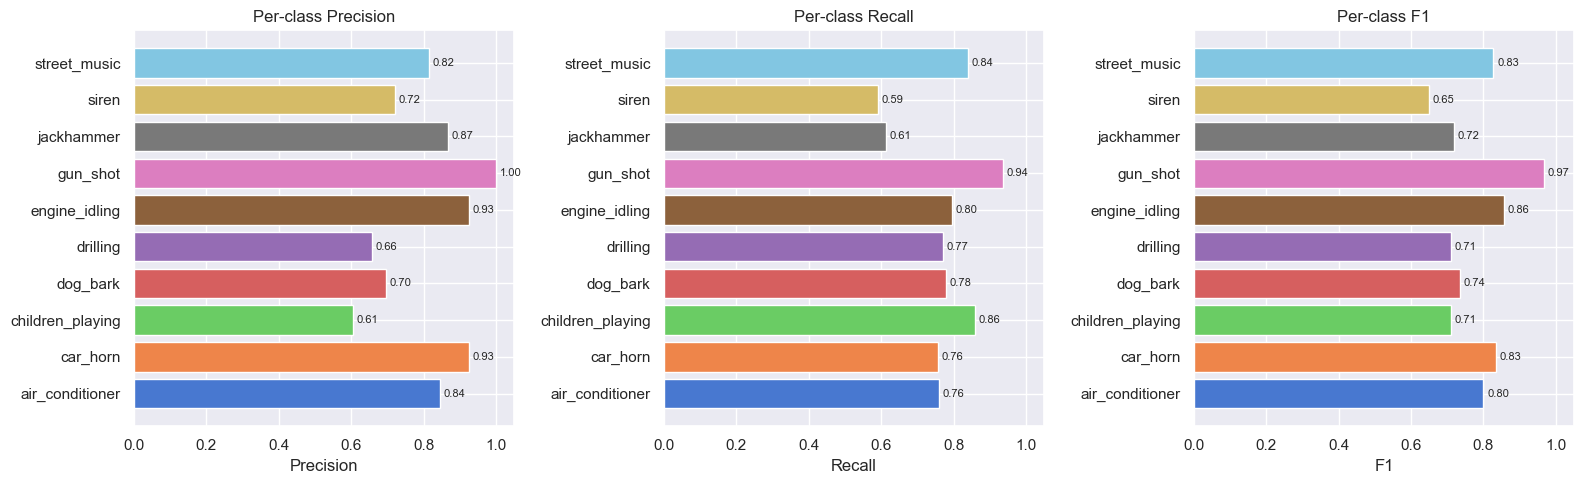

In [54]:
# Per-class metrics bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = sns.color_palette('muted', 10)

for ax, (metric, values) in zip(axes, [('Precision', prec), ('Recall', rec), ('F1', f1)]):
    ax.barh(CLASS_NAMES, values, color=colors)
    ax.set_xlim(0, 1.05)
    ax.set_title(f'Per-class {metric}')
    ax.set_xlabel(metric)
    for i, v in enumerate(values):
        ax.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

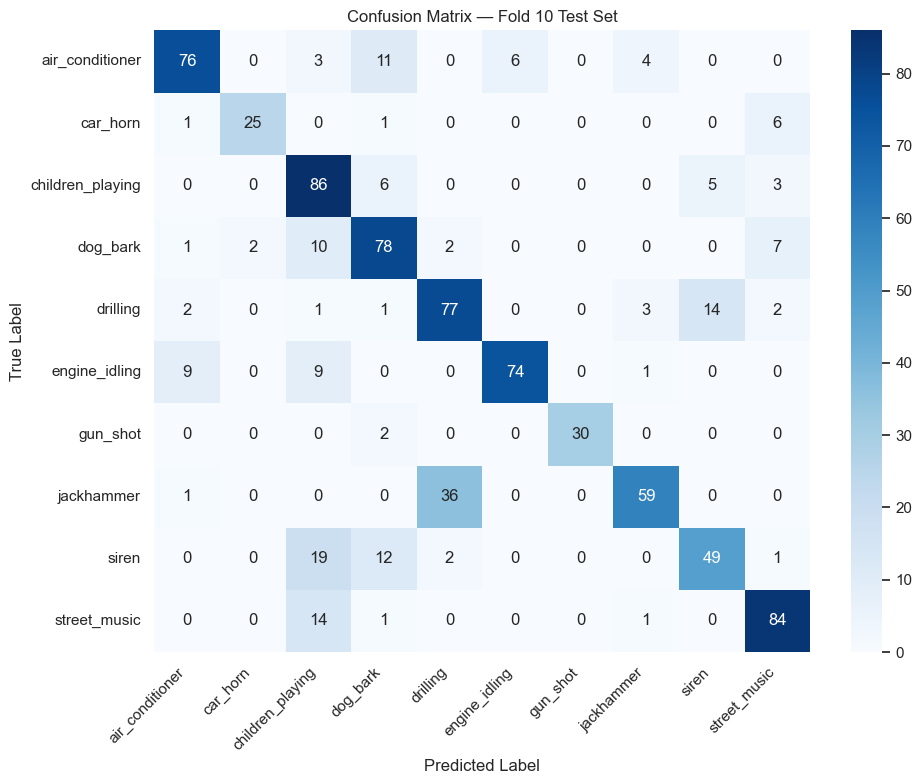

In [55]:
# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES
)
plt.title('Confusion Matrix — Fold 10 Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

  ROC-AUC air_conditioner     : 0.9760
  ROC-AUC car_horn            : 0.9923
  ROC-AUC children_playing    : 0.9703
  ROC-AUC dog_bark            : 0.9622
  ROC-AUC drilling            : 0.9317
  ROC-AUC engine_idling       : 0.9782
  ROC-AUC gun_shot            : 0.9970
  ROC-AUC jackhammer          : 0.9939
  ROC-AUC siren               : 0.8895
  ROC-AUC street_music        : 0.9834

Macro-average ROC-AUC: 0.9674


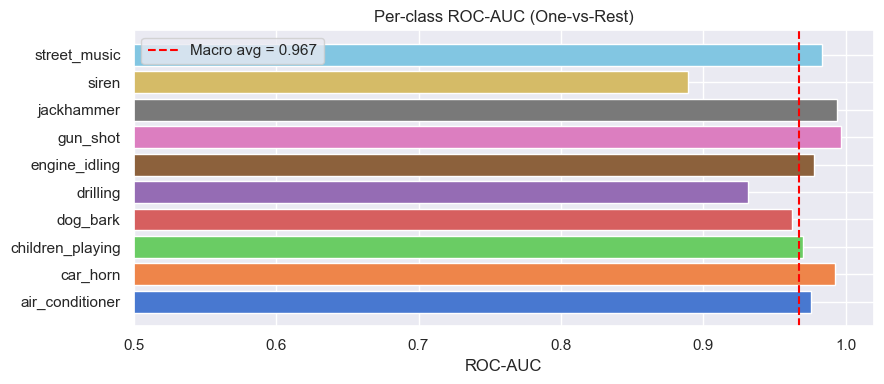

In [56]:
# ROC-AUC one-vs-rest
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=list(range(10)))
roc_auc_per_class = []

for i, name in enumerate(CLASS_NAMES):
    auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    roc_auc_per_class.append(auc)
    print(f'  ROC-AUC {name:<20s}: {auc:.4f}')

macro_auc = roc_auc_score(y_test_bin, y_proba, multi_class='ovr', average='macro')
print(f'\nMacro-average ROC-AUC: {macro_auc:.4f}')

plt.figure(figsize=(9, 4))
plt.barh(CLASS_NAMES, roc_auc_per_class, color=sns.color_palette('muted', 10))
plt.axvline(x=macro_auc, color='red', linestyle='--', label=f'Macro avg = {macro_auc:.3f}')
plt.xlim(0.5, 1.02)
plt.xlabel('ROC-AUC')
plt.title('Per-class ROC-AUC (One-vs-Rest)')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Dataset Visualizations

The same three charts served by the `/insights` API endpoint.

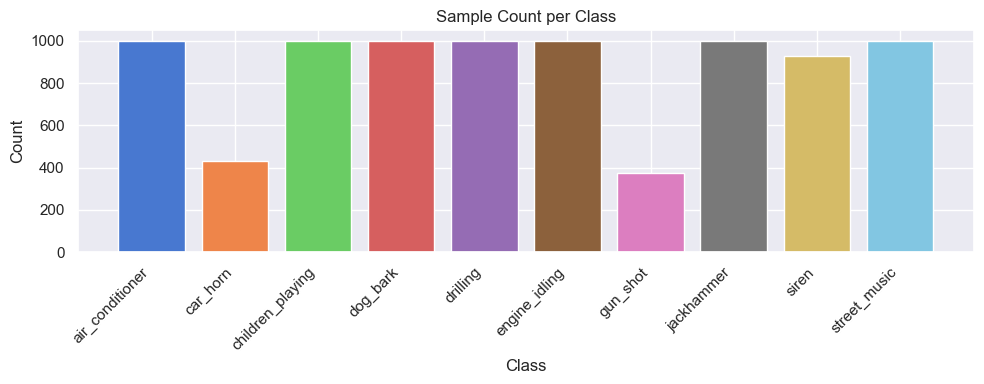

In [57]:
# Chart 1: Sample count per class
class_counts = meta.groupby('classID').size()
plt.figure(figsize=(10, 4))
plt.bar([CLASS_NAMES[i] for i in class_counts.index], class_counts.values,
        color=sns.color_palette('muted', 10))
plt.title('Sample Count per Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


The dataset is broadly balanced with ~800-1000 samples per class.
Drilling and jackhammer have slightly more samples; car horn has fewer.

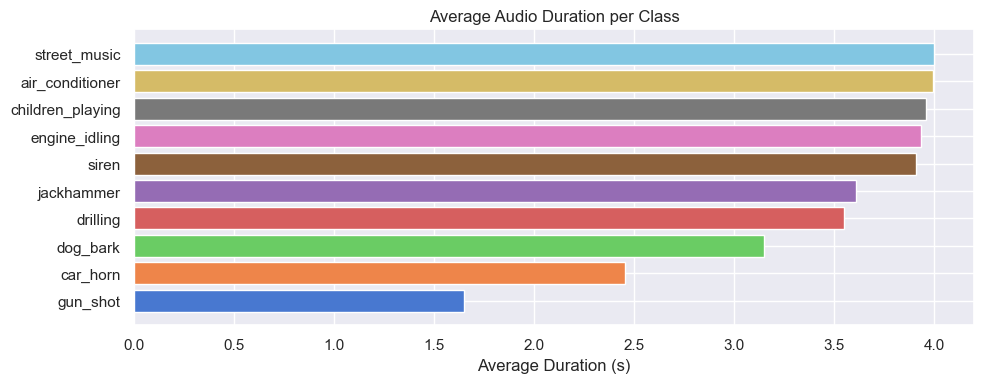

In [58]:
# Chart 2: Average duration per class
if 'duration' in meta.columns:
    avg_dur = meta.groupby('classID')['duration'].mean().sort_values()
    plt.figure(figsize=(10, 4))
    plt.barh([CLASS_NAMES[i] for i in avg_dur.index], avg_dur.values,
             color=sns.color_palette('muted', 10))
    plt.xlabel('Average Duration (s)')
    plt.title('Average Audio Duration per Class')
    plt.tight_layout()
    plt.show()

    

Most classes average 3-4 seconds. Car horn clips are shorter (brief honks).
Continuous sounds like air conditioner and engine idling average closer to 4 seconds.

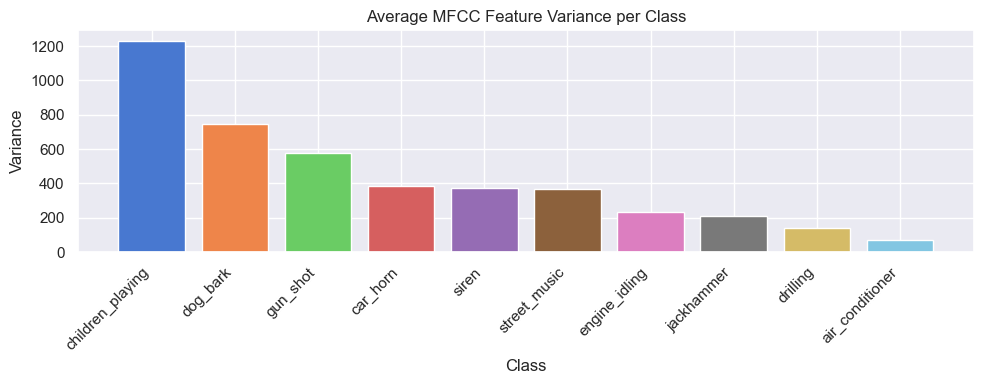

In [59]:
# Chart 3: MFCC variance per class (sample 10 files per class for speed)
mfcc_var = {}
for class_id, name in enumerate(CLASS_NAMES):
    subset = meta[meta['classID'] == class_id].head(10)
    variances = []
    for _, row in subset.iterrows():
        fp = os.path.join(audio_dir, f'fold{row["fold"]}', row['slice_file_name'])
        if not os.path.exists(fp):
            continue
        try:
            feat = extract_features(fp)
            variances.append(np.var(feat))
        except Exception:
            pass
    mfcc_var[name] = np.mean(variances) if variances else 0.0

names_sorted = sorted(mfcc_var, key=mfcc_var.get, reverse=True)
vals_sorted  = [mfcc_var[n] for n in names_sorted]

plt.figure(figsize=(10, 4))
plt.bar(names_sorted, vals_sorted, color=sns.color_palette('muted', 10))
plt.title('Average MFCC Feature Variance per Class')
plt.xlabel('Class')
plt.ylabel('Variance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Street music and children playing show higher MFCC variance due to timbral diversity.
Steady mechanical sounds like engine idling exhibit lower variance, confirming their repetitive spectral content.

## 7. Model Save and Reload Verification

In [60]:
model_path = '../models/urbansound_model.pkl'

# Save
joblib.dump(grid_search, model_path)
print(f'Model saved to {model_path}')
print(f'File size: {os.path.getsize(model_path) / 1024:.1f} KB')

# Reload
loaded_model = joblib.load(model_path)
print(f'\nLoaded model type: {type(loaded_model).__name__}')
print(f'Best params: {loaded_model.best_params_}')

# Verify prediction matches on a test sample
sample_idx = 42
original_pred = best_model.predict(X_test[sample_idx:sample_idx+1])[0]
reloaded_pred = loaded_model.predict(X_test[sample_idx:sample_idx+1])[0]
print(f'\nSample {sample_idx}: original={CLASS_NAMES[original_pred]}, reloaded={CLASS_NAMES[reloaded_pred]}')
assert original_pred == reloaded_pred, 'Prediction mismatch after reload!'
print('Predictions match.')

# Final accuracy summary
final_acc = accuracy_score(y_test, loaded_model.predict(X_test))
print(f'\nFinal test accuracy (reloaded model): {final_acc:.4f} ({final_acc*100:.2f}%)')

Model saved to ../models/urbansound_model.pkl
File size: 6968.4 KB

Loaded model type: GridSearchCV
Best params: {'svc__C': 1, 'svc__gamma': 'scale'}

Sample 42: original=engine_idling, reloaded=engine_idling
Predictions match.

Final test accuracy (reloaded model): 0.7622 (76.22%)


In [61]:
print('First 40 dims (MFCCs):  ', X_train[0, :40].round(2))
print('Next 40 dims (delta):   ', X_train[0, 40:80].round(2))
print('Last 40 dims (delta2):  ', X_train[0, 80:120].round(2))

print('Delta all zeros?', np.allclose(X_train[:, 40:80], 0))
print('Delta2 all zeros?', np.allclose(X_train[:, 80:120], 0))

# Also check variance across dims — low variance = uninformative features
print('Std per feature group:')
print('  MFCCs:  ', X_train[:, :40].std(axis=0).mean().round(4))
print('  Delta:  ', X_train[:, 40:80].std(axis=0).mean().round(4))
print('  Delta2: ', X_train[:, 80:120].std(axis=0).mean().round(4))

First 40 dims (MFCCs):   [-2.1194e+02  6.2580e+01 -1.2281e+02 -6.0750e+01 -1.3890e+01 -2.9790e+01
 -3.9800e+00  1.1680e+01  1.2960e+01  8.3400e+00 -6.5300e+00 -3.0000e+00
 -1.2890e+01  5.8900e+00 -2.4800e+00 -4.4100e+00 -1.5010e+01 -9.4000e-01
 -2.5800e+00  6.1000e+00 -1.0790e+01 -8.0600e+00  5.8400e+00 -3.1200e+00
 -5.9800e+00 -8.0000e-02 -3.6900e+00  4.7500e+00 -6.5300e+00 -5.0800e+00
  4.9000e-01  7.5100e+00 -8.9000e-01  2.3900e+00 -6.3900e+00 -2.1300e+00
  2.2800e+00 -7.9000e-01 -1.5400e+00  1.3200e+00]
Next 40 dims (delta):    [130.13  25.51  15.54  13.53   9.77  18.68   5.34   6.16   4.3    5.79
   6.87   3.67   6.58   2.91   4.83   4.42   4.49   4.86   3.13   3.21
   6.03   2.16   2.3    2.76   4.39   4.09   2.62   2.15   5.21   4.82
   5.87   3.28   3.87   4.62   3.1    3.46   3.52   3.65   2.81   2.53]
Last 40 dims (delta2):   [29.95  7.27  3.95  3.17  2.    4.78  1.26  0.64  1.01  1.07  1.27  0.91
  1.12  0.3   1.27  0.6   1.06  0.43  0.69  0.66  1.17  0.22  0.32  0.55
  0.63